In [8]:
import datasets as hfds
from matplotlib import pyplot as plt
import numpy as np
import torchvision.transforms.v2 as v2

import flat_mae.transforms as flat_transforms
import flat_mae.data as flat_data
import flat_mae.nisc as nisc

In [2]:
plt.style.use("../clane.mplstyle")
PLOTW = 3.25  # 6.75 two column width, 0.25 pad

In [9]:
def prefix_crop(sample, num_frames: int = 16):
    sample["bold"] = sample["bold"][:num_frames]
    return sample


def make_transform(space: str = "flat"):
    # hack, have to redefine to exclude center crop bc mni clips is only 16 frames
    # (idk why ig I forgot to make it 24 frames like the others)
    transform = v2.Compose(
        [
            flat_transforms.ToTensor(),
            prefix_crop,
            flat_transforms.Normalize(mode="frame"),
            flat_transforms.Clip(vmax=3.0),
            flat_transforms.get_unmask(space),
        ]
    )
    return transform

In [10]:
# load datasets
dataset_root = "s3://medarc/fmri-datasets/eval"
input_spaces = ["schaefer400", "flat", "mni_cortex"]

datasets = {}
transforms = {}

for space in input_spaces:
    transforms[space] = transform = make_transform(space)
    dataset = hfds.load_dataset(
        "arrow",
        data_files=f"{dataset_root}/hcpya-clips.{space}.arrow/validation/data-00000-of-*.arrow",
        split="train",
    )
    dataset = flat_data.HFDataset(dataset, transforms[space])
    datasets[space] = dataset
    print(dataset)

HFDataset(
    dataset=Dataset({
    features: ['sub', 'mod', 'task', 'mag', 'dir', 'path', 'start', 'end', 'n_frames', 'tr', 'bold', 'mean', 'std'],
    num_rows: 2288
}),
    transform=Compose(
      ToTensor()
      <function prefix_crop at 0x76295b56bd80>
      Normalize(mode='frame')
      Clip(vmax=3.0)
      Schaefer400Unmask(400)
)
)
HFDataset(
    dataset=Dataset({
    features: ['sub', 'mod', 'task', 'mag', 'dir', 'path', 'start', 'end', 'n_frames', 'tr', 'bold', 'mean', 'std'],
    num_rows: 68
}),
    transform=Compose(
      ToTensor()
      <function prefix_crop at 0x76295b56bd80>
      Normalize(mode='frame')
      Clip(vmax=3.0)
      FlatUnmask((224, 560))
)
)
HFDataset(
    dataset=Dataset({
    features: ['sub', 'mod', 'task', 'mag', 'dir', 'path', 'start', 'end', 'n_frames', 'tr', 'bold', 'mean', 'std'],
    num_rows: 56
}),
    transform=Compose(
      ToTensor()
      <function prefix_crop at 0x76295b56bd80>
      Normalize(mode='frame')
      Clip(vmax=3.0)
     

In [11]:
# nice sample with clear visual cortex deactivation
sample_idx = 32

# check all datasets have the same samples
for space in input_spaces:
    sample = datasets[space][sample_idx]
    print(space, sample["path"], sample["bold"].shape)

schaefer400 971160/MNINonLinear/Results/rfMRI_REST3_7T_PA/rfMRI_REST3_7T_PA_Atlas_MSMAll.dtseries.nii torch.Size([1, 16, 400, 1])
flat 971160/MNINonLinear/Results/rfMRI_REST3_7T_PA/rfMRI_REST3_7T_PA_Atlas_MSMAll.dtseries.nii torch.Size([1, 16, 224, 560])
mni_cortex 971160/MNINonLinear/Results/rfMRI_REST3_7T_PA/rfMRI_REST3_7T_PA.nii.gz torch.Size([1, 16, 466, 512])


In [12]:
# convert to flat maps
flat_bold = {}
for space in input_spaces:
    sample = datasets[space][sample_idx]
    bold = sample["bold"]
    unmask = flat_transforms.get_unmask(space)
    flat_bold[space] = unmask.to_flat(bold)
    print(space, flat_bold[space].shape)

schaefer400 torch.Size([1, 16, 224, 560])
flat torch.Size([1, 16, 224, 560])
mni_cortex torch.Size([1, 16, 224, 560])


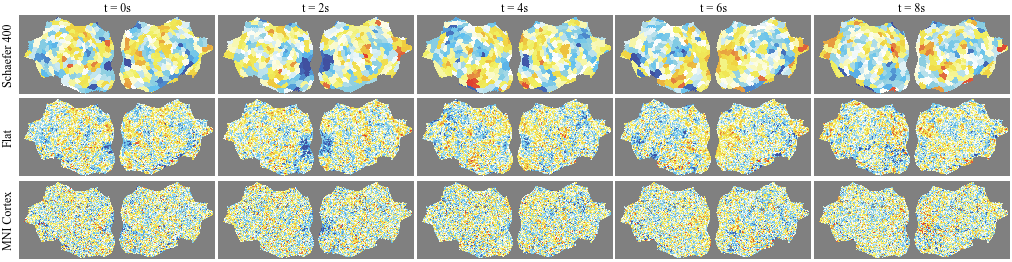

In [13]:
# plot
# 3 rows, n columns
figw = 2 * PLOTW + 0.25
nr = 3
nc = 5

H, W = 224, 560
plotw = figw / nc
ploth = (H / W) * plotw

f, axs = plt.subplots(nr, nc, figsize=(nc * plotw, (nr + 0.3) * ploth))

step = 2
tr = 1.0

space_names = {
    "flat": "Flat",
    "schaefer400": "Schaefer 400",
    "mni_cortex": "MNI Cortex",
}


for ii, space in enumerate(input_spaces):
    for jj in range(nc):
        ax = axs[ii, jj]
        plt.sca(axs[ii, jj])
        idx = jj * step
        img = flat_bold[space][0, idx].numpy()
        img = np.where(img != 0, img, np.nan)
        plt.imshow(img, vmin=-3, vmax=3, cmap=nisc.FC_CMAP, interpolation="none")
        plt.xticks([])
        plt.yticks([])

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)

        if jj == 0:
            plt.ylabel(space_names[space], fontsize="small")
        if ii == 0:
            plt.title(f"t = {tr * idx:.0f}s", fontsize="small", pad=2)

plt.tight_layout(pad=0.2)
plt.savefig("results/input_space_flat_viz.pdf")

This plot shows 5 frames from a selected fMRI sample (spaced 2s apart) for each of the three input data spaces. We render the Schaefer 400 and MNI Cortex data into flat map space for visualization convenience and consistency only. For Schaefer 400, each flat map vertex is assigned the value of the ROI it belongs too. For MNI Cortex, we transform the MNI 152 volume data to fsLR64k surface space using neuromaps, and then resample to the flat map. (Consequently, the MNI Cortex plot is lossy, averaging over the cortical thickness.)

> *Note:* MNI cortex is missing some data, I guess due to filtering patches that are too sparse.

> *Aside:* maybe we should somehow train on all of these as multiple views.